# lineitem - Experiment 2: Memory Cliff Analysis


In [3]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
LOG_DIR = './result'
OUTPUT_DIR = './exp2_output'


# ==========================================
# PLOTTING
# ==========================================
plt.style.use('../../logs/custom_plt_style.mplstyle')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. Log File Parser

In [4]:
def parse_log_file(filepath):
    """Parse a single log file and extract all metrics including detailed I/O."""
    filename = os.path.basename(filepath)
    
    # Parse filename to extract experiment parameters
    exp_match = re.search(r'(Exp\d+\.?\d*)', filename)  # Support Exp3.1 format
    thr_match = re.search(r'Thr(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)
    imb_match = re.search(r'Imbalance([\d.]+)', filename)
    
    if not (exp_match and thr_match and mem_match):
        return None
    
    result = {
        'experiment': exp_match.group(1),
        'threads': int(thr_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'imbalance_factor': float(imb_match.group(1)) if imb_match else None,
        'filename': filename
    }
    
    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()
        
        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )
        
        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))
        
        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))
        
        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))
        else:
            result['merge_passes'] = 1
        
        # Extract partition imbalance - WEIGHTED average by partition size
        # Each merge operation has 5 columns: PAvg, PMax, Imbal, Slow, Fast
        # PAvg is at positions 0, 5, 10, 15 (0-indexed)
        # Imbal is at positions 2, 7, 12, 17 (0-indexed)
        merge_section = content.split('Merge Operations Summary')[-1]
        avg_line_match = re.search(r'\[avg\]\s+([\d.\s]+)', merge_section)
        if avg_line_match:
            # Extract all numbers from the [avg] line
            numbers_str = avg_line_match.group(1).strip()
            numbers = [float(n) for n in numbers_str.split()]
            
            # Extract partition sizes and imbalance values
            partition_sizes = []
            imbalances = []
            for i in range(0, len(numbers), 5):
                if i + 2 < len(numbers):
                    partition_sizes.append(numbers[i])      # M1PAvg, M2PAvg, M3PAvg, M4PAvg
                    imbalances.append(numbers[i + 2])       # M1Imbal, M2Imbal, M3Imbal, M4Imbal
            
            # Calculate weighted average: sum(PAvg * Imbal) / sum(PAvg)
            if partition_sizes and imbalances:
                weighted_sum = sum(p * i for p, i in zip(partition_sizes, imbalances))
                total_weight = sum(partition_sizes)
                result['partition_imbalance'] = weighted_sum / total_weight
        
        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )
        
        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0
            
            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] + 
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])
    
    return result if 'total_time' in result else None


def load_all_experiments(log_dir):
    """Load all log files and organize by experiment."""
    log_files = glob.glob(os.path.join(log_dir, '*.log'))
    
    all_data = []
    for filepath in log_files:
        parsed = parse_log_file(filepath)
        if parsed:
            all_data.append(parsed)
    
    df = pd.DataFrame(all_data)
    return df


# Load all data
df_all = load_all_experiments(LOG_DIR)
print(f"Loaded {len(df_all)} experiment results")
print(f"\nExperiments found: {sorted(df_all['experiment'].unique())}")

Loaded 41 experiment results

Experiments found: ['Exp1', 'Exp2', 'Exp3', 'Exp3.1', 'Exp4', 'Exp5']


In [5]:
def parse_exp1_subexp_log(filepath):
    """Parse Exp1.1 and Exp1.2 log files with RunGen/Merge thread counts."""
    filename = os.path.basename(filepath)

    # Parse filename: Exp1.1_RunGen40_Merge16_Mem2GB.log
    exp_match = re.search(r'(Exp\d+\.\d+)', filename)
    rungen_match = re.search(r'RunGen(\d+)', filename)
    merge_match = re.search(r'Merge(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)

    if not (exp_match and rungen_match and merge_match and mem_match):
        return None

    result = {
        'experiment': exp_match.group(1),
        'rungen_threads': int(rungen_match.group(1)),
        'merge_threads': int(merge_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'filename': filename
    }

    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()

        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )

        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads_actual'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))

        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))

        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))

        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )

        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0

            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] +
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])

    return result if 'total_time' in result else None

### Plot 2: Exp2 - Memory Cliff

In [6]:
# Exp2: Memory Cliff Analysis (Fixed 40 threads, varying memory)
print("="*100)
print("EXP2: MEMORY CLIFF (Fixed 40 Threads, Varying Memory)")
print("="*100)
df_exp2 = df_all[df_all['experiment'] == 'Exp2'].sort_values('memory_gb')
display_cols = ['memory_gb', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp2[display_cols].to_string(index=False))
if not df_exp2.empty:
    print(f"\nOptimal: {df_exp2.loc[df_exp2['total_time'].idxmin(), 'memory_gb']:.0f}GB @ {df_exp2['total_time'].min():.1f}s")
    print(f"Worst: {df_exp2.loc[df_exp2['total_time'].idxmax(), 'memory_gb']:.0f}GB @ {df_exp2['total_time'].max():.1f}s")

EXP2: MEMORY CLIFF (Fixed 40 Threads, Varying Memory)
 memory_gb  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
         1      3500      797.29       368.47      428.81        3.76             9                1.76
         4       919      619.49       388.85      230.64        4.84             1                1.02
         6       639      630.96       398.34      232.61        4.75             1                1.02
         8       480      636.89       413.83      223.06        4.71             1                1.01
        16       279      665.78       450.49      215.29        4.51             1                1.01
        24       200      749.92       536.12      213.80        4.00             1                1.01
        32       160      756.77       549.36      207.41        3.96             1                1.00

Optimal: 4GB @ 619.5s
Worst: 1GB @ 797.3s


In [7]:
colors = {
    'total': '#1f77b4',
    'rungen': '#2ca02c', 
    'merge': '#d62728',
    'exp2': '#ff7f0e',
    'exp3': '#9467bd',
    'exp4': '#8c564b'
}

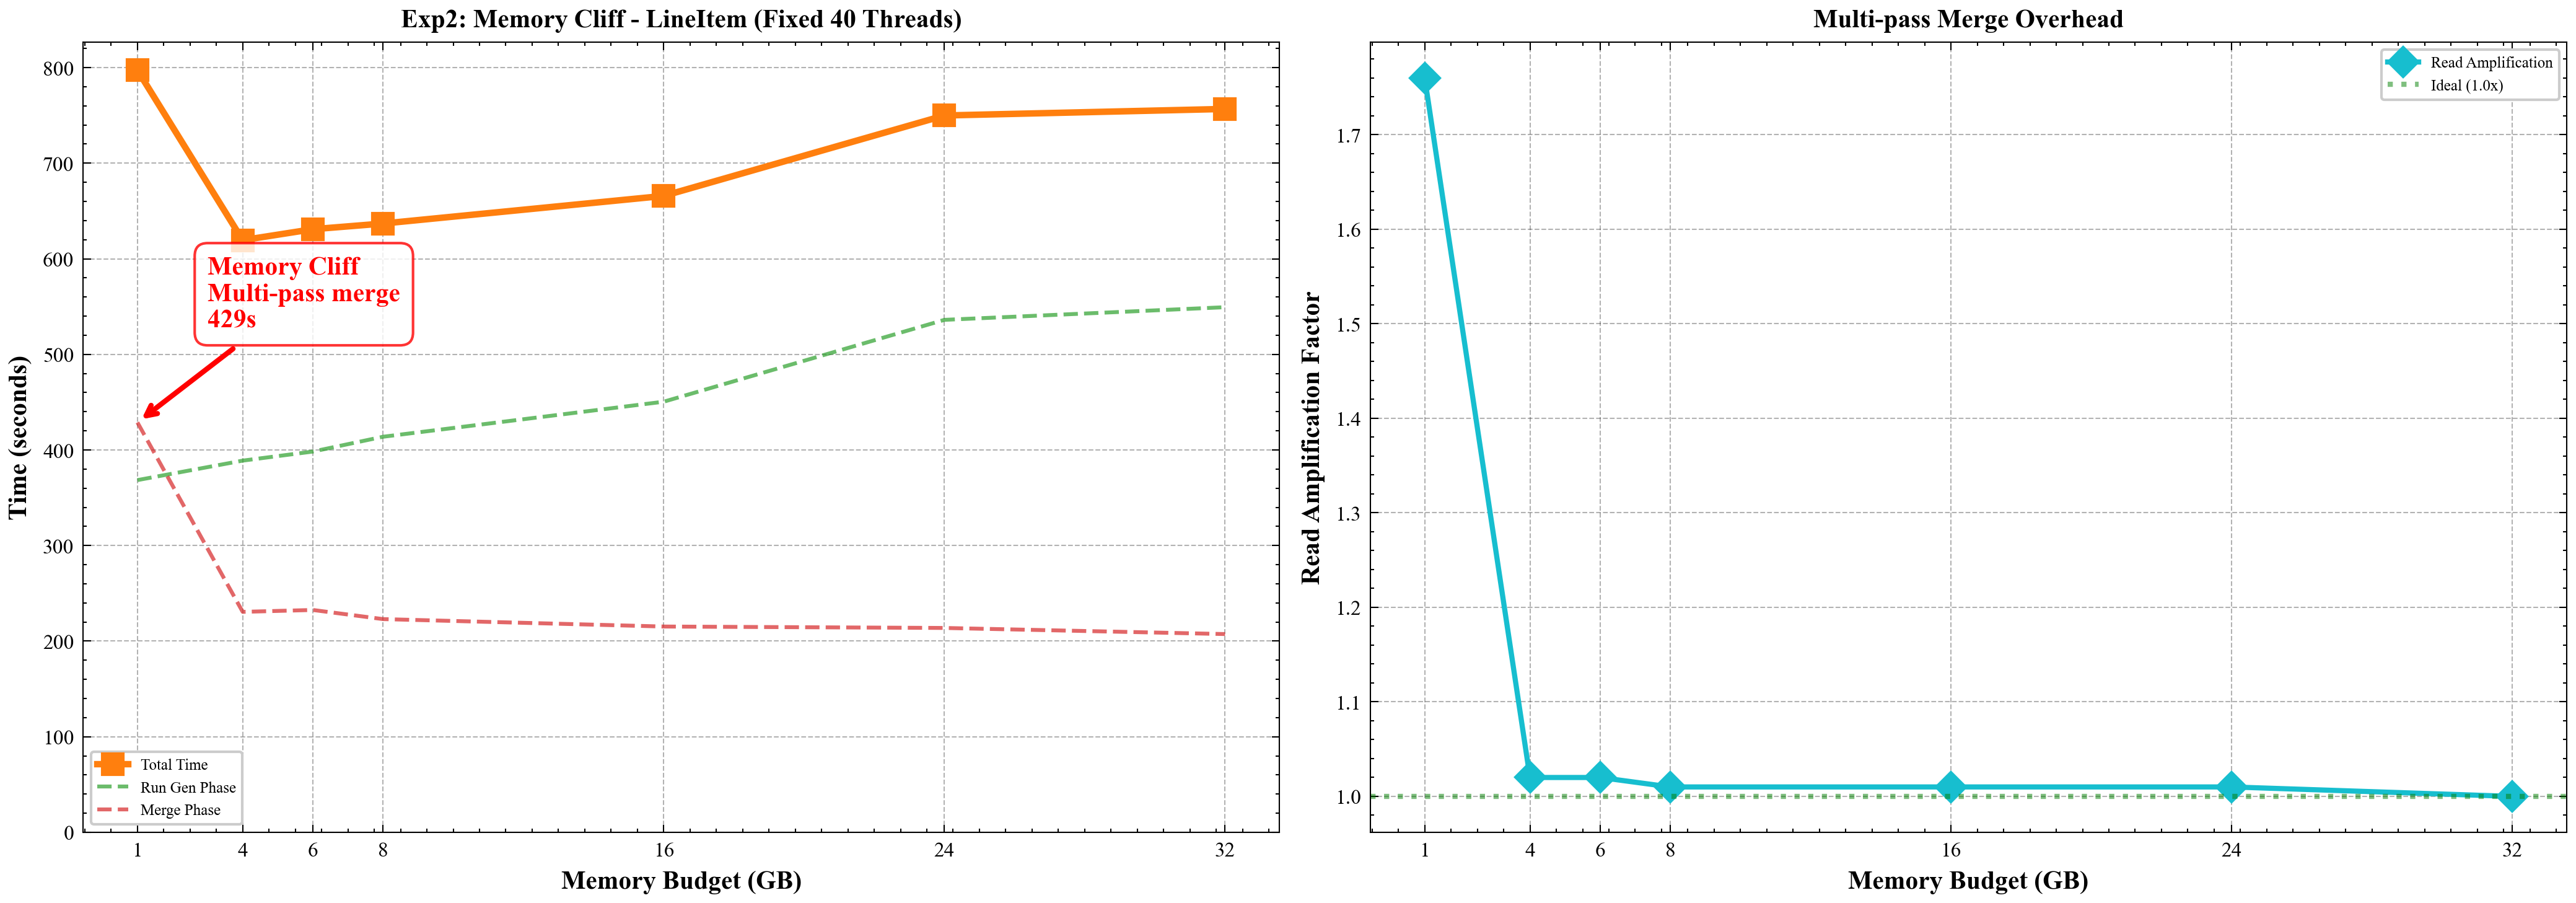


📊 Exp2 Insight: Memory < 1GB triggers multi-pass merge with 1.76x read amplification.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1a: Time breakdown
df_exp2_sorted = df_exp2.sort_values('memory_gb')
ax1.plot(df_exp2_sorted['memory_gb'], df_exp2_sorted['total_time'], 
         's-', lw=2.5, markersize=8, color=colors['exp2'], label='Total Time')
ax1.plot(df_exp2_sorted['memory_gb'], df_exp2_sorted['rungen_time'], 
         '--', lw=1.5, alpha=0.7, color=colors['rungen'], label='Run Gen Phase')
ax1.plot(df_exp2_sorted['memory_gb'], df_exp2_sorted['merge_time'], 
         '--', lw=1.5, alpha=0.7, color=colors['merge'], label='Merge Phase')

# Annotate memory cliff
multipass = df_exp2_sorted[df_exp2_sorted['merge_passes'] > 1]
if not multipass.empty:
    cliff_mem = multipass.iloc[0]['memory_gb']
    cliff_time = multipass.iloc[0]['merge_time']
    ax1.annotate(f'Memory Cliff\nMulti-pass merge\n{cliff_time:.0f}s',
                 xy=(cliff_mem, cliff_time),
                 xytext=(cliff_mem + 2, cliff_time + 100),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2),
                 ha='left', fontweight='bold', color='red', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='red', alpha=0.8))

ax1.set_xlabel('Memory Budget (GB)', fontweight='bold')
ax1.set_ylabel('Time (seconds)', fontweight='bold')
ax1.set_title('Exp2: Memory Cliff - LineItem (Fixed 40 Threads)', fontweight='bold')
ax1.set_xticks(sorted(df_exp2_sorted['memory_gb'].unique()))
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='best')
ax1.set_ylim(bottom=0)

# Plot 1b: Read amplification
ax2.plot(df_exp2_sorted['memory_gb'], df_exp2_sorted['read_amplification'], 
         'D-', lw=2, markersize=8, color='#17becf', label='Read Amplification')
ax2.axhline(y=1.0, color='green', linestyle=':', lw=2, alpha=0.5, label='Ideal (1.0x)')
ax2.set_xlabel('Memory Budget (GB)', fontweight='bold')
ax2.set_ylabel('Read Amplification Factor', fontweight='bold')
ax2.set_title('Multi-pass Merge Overhead', fontweight='bold')
ax2.set_xticks(sorted(df_exp2_sorted['memory_gb'].unique()))
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp2_memory_cliff.png'), dpi=300, bbox_inches='tight')
plt.show()

if not multipass.empty:
    print(f"\n📊 Exp2 Insight: Memory < {multipass.iloc[0]['memory_gb']:.0f}GB triggers multi-pass merge with {multipass.iloc[0]['read_amplification']:.2f}x read amplification.")
else:
    print(f"\n📊 Exp2 Insight: All configurations used single-pass merge (no memory cliff observed).")